Para abordar el análisis de marketing data-driven en fintech, seguiremos estos pasos:

Exploración de Datos:

Analizar la distribución de las variables.
Identificar correlaciones entre las características y la variable objetivo ("y").
Detectar y manejar valores faltantes.

Definición de KPIs:

- -Tasa de conversión (porcentaje de clientes que contratan el producto).
- -Tasa de respuesta por campaña.
- -Duración promedio de las llamadas.
- -Número promedio de contactos por cliente.

Visualización de Datos:

Crear gráficos para visualizar la distribución de las variables y las correlaciones.
Diseñar un dashboard ejecutivo con los KPIs definidos.

Modelado Predictivo:

Implementar un modelo de clasificación para predecir la probabilidad de contratación.
Evaluar el rendimiento del modelo utilizando métricas como precisión, recall y F1-score.
Comencemos con la exploración de datos y la definición de KPIs.

In [49]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

import missingno as msno

# Expresiones regulares
import re
from fuzzywuzzy import process

import warnings
warnings.filterwarnings('ignore')

import os   

# Preprocesamiento de datos y ML
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline 
from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import ADASYN
from imblearn.combine import SMOTETomek


# Evaluacion
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, f1_score, confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [50]:
path = 'bank-additional_bank-additional-full.csv'
delimiter = ';'

data = pd.read_csv(path, delimiter=delimiter)

# Mostramos las primeras filas del DataFrame para verificar la carga de datos
data.head() 

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [51]:
# Obtenemos una muestra de 20 filas del DataFrame 'data'
sample_data = data.sample(n=20)

# Mostramos la muestra obtenida
print(sample_data)

       age          job   marital            education  default  housing  \
33528   32  blue-collar   married             basic.4y       no       no   
28400   33   technician    single    university.degree       no      yes   
14139   31    housemaid   married          high.school       no      yes   
16219   48   technician    single  professional.course  unknown      yes   
26890   43   technician   married  professional.course       no       no   
19107   50  blue-collar   married             basic.4y  unknown      yes   
20154   59      retired   married             basic.9y       no      yes   
34846   37       admin.    single          high.school       no      yes   
25168   50   technician   married  professional.course       no  unknown   
11421   38       admin.  divorced    university.degree       no       no   
27514   57   management   married    university.degree  unknown      yes   
26885   36       admin.   married              unknown  unknown      yes   
31262   42  

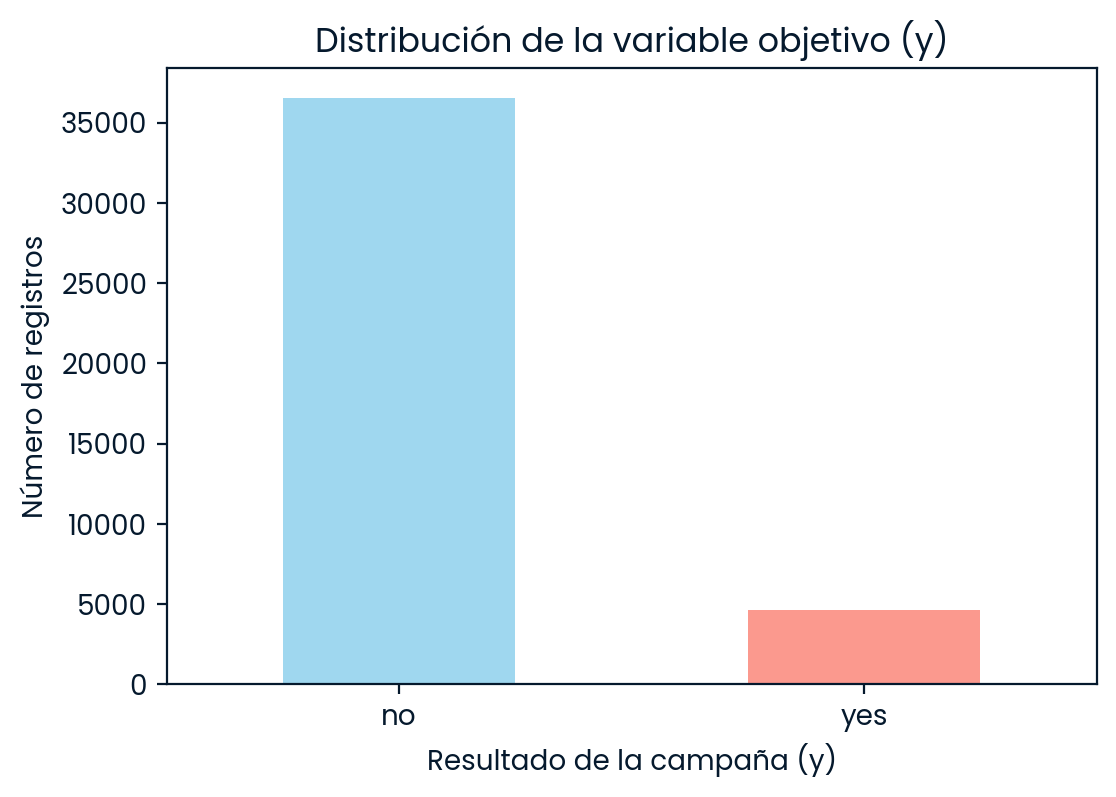

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

In [4]:
# Distribución de la variable objetivo ('y')
y_distribution = data['y'].value_counts(normalize=True) * 100  # Porcentaje
y_counts = data['y'].value_counts()  # Conteo absoluto

# Gráfico de la distribución
plt.figure(figsize=(6, 4))
y_counts.plot(kind='bar', color=['skyblue', 'salmon'], alpha=0.8)
plt.title('Distribución de la variable objetivo (y)')
plt.xlabel('Resultado de la campaña (y)')
plt.ylabel('Número de registros')
plt.xticks(rotation=0)
plt.show()

# Resultados en porcentaje
y_distribution


In [52]:
# Filtamos los casos donde 'y' es 'yes'
yes_cases = data[data['y'] == 'yes']

# Resumen de estos casos
yes_summary = {
    "shape": yes_cases.shape,
    "sample_data": yes_cases.head().to_dict(orient="records"),
    "descriptive_stats": yes_cases.describe(include="all").to_dict()
}

# Fomateamos el resumen para mayor legibilidad
from pprint import pprint
pprint(yes_summary)

{'descriptive_stats': {'age': {'25%': 31.0,
                               '50%': 37.0,
                               '75%': 50.0,
                               'count': 4640.0,
                               'freq': nan,
                               'max': 98.0,
                               'mean': 40.91314655172414,
                               'min': 17.0,
                               'std': 13.837476239030549,
                               'top': nan,
                               'unique': nan},
                       'campaign': {'25%': 1.0,
                                    '50%': 2.0,
                                    '75%': 2.0,
                                    'count': 4640.0,
                                    'freq': nan,
                                    'max': 23.0,
                                    'mean': 2.0517241379310347,
                                    'min': 1.0,
                                    'std': 1.6662446534915543,
            

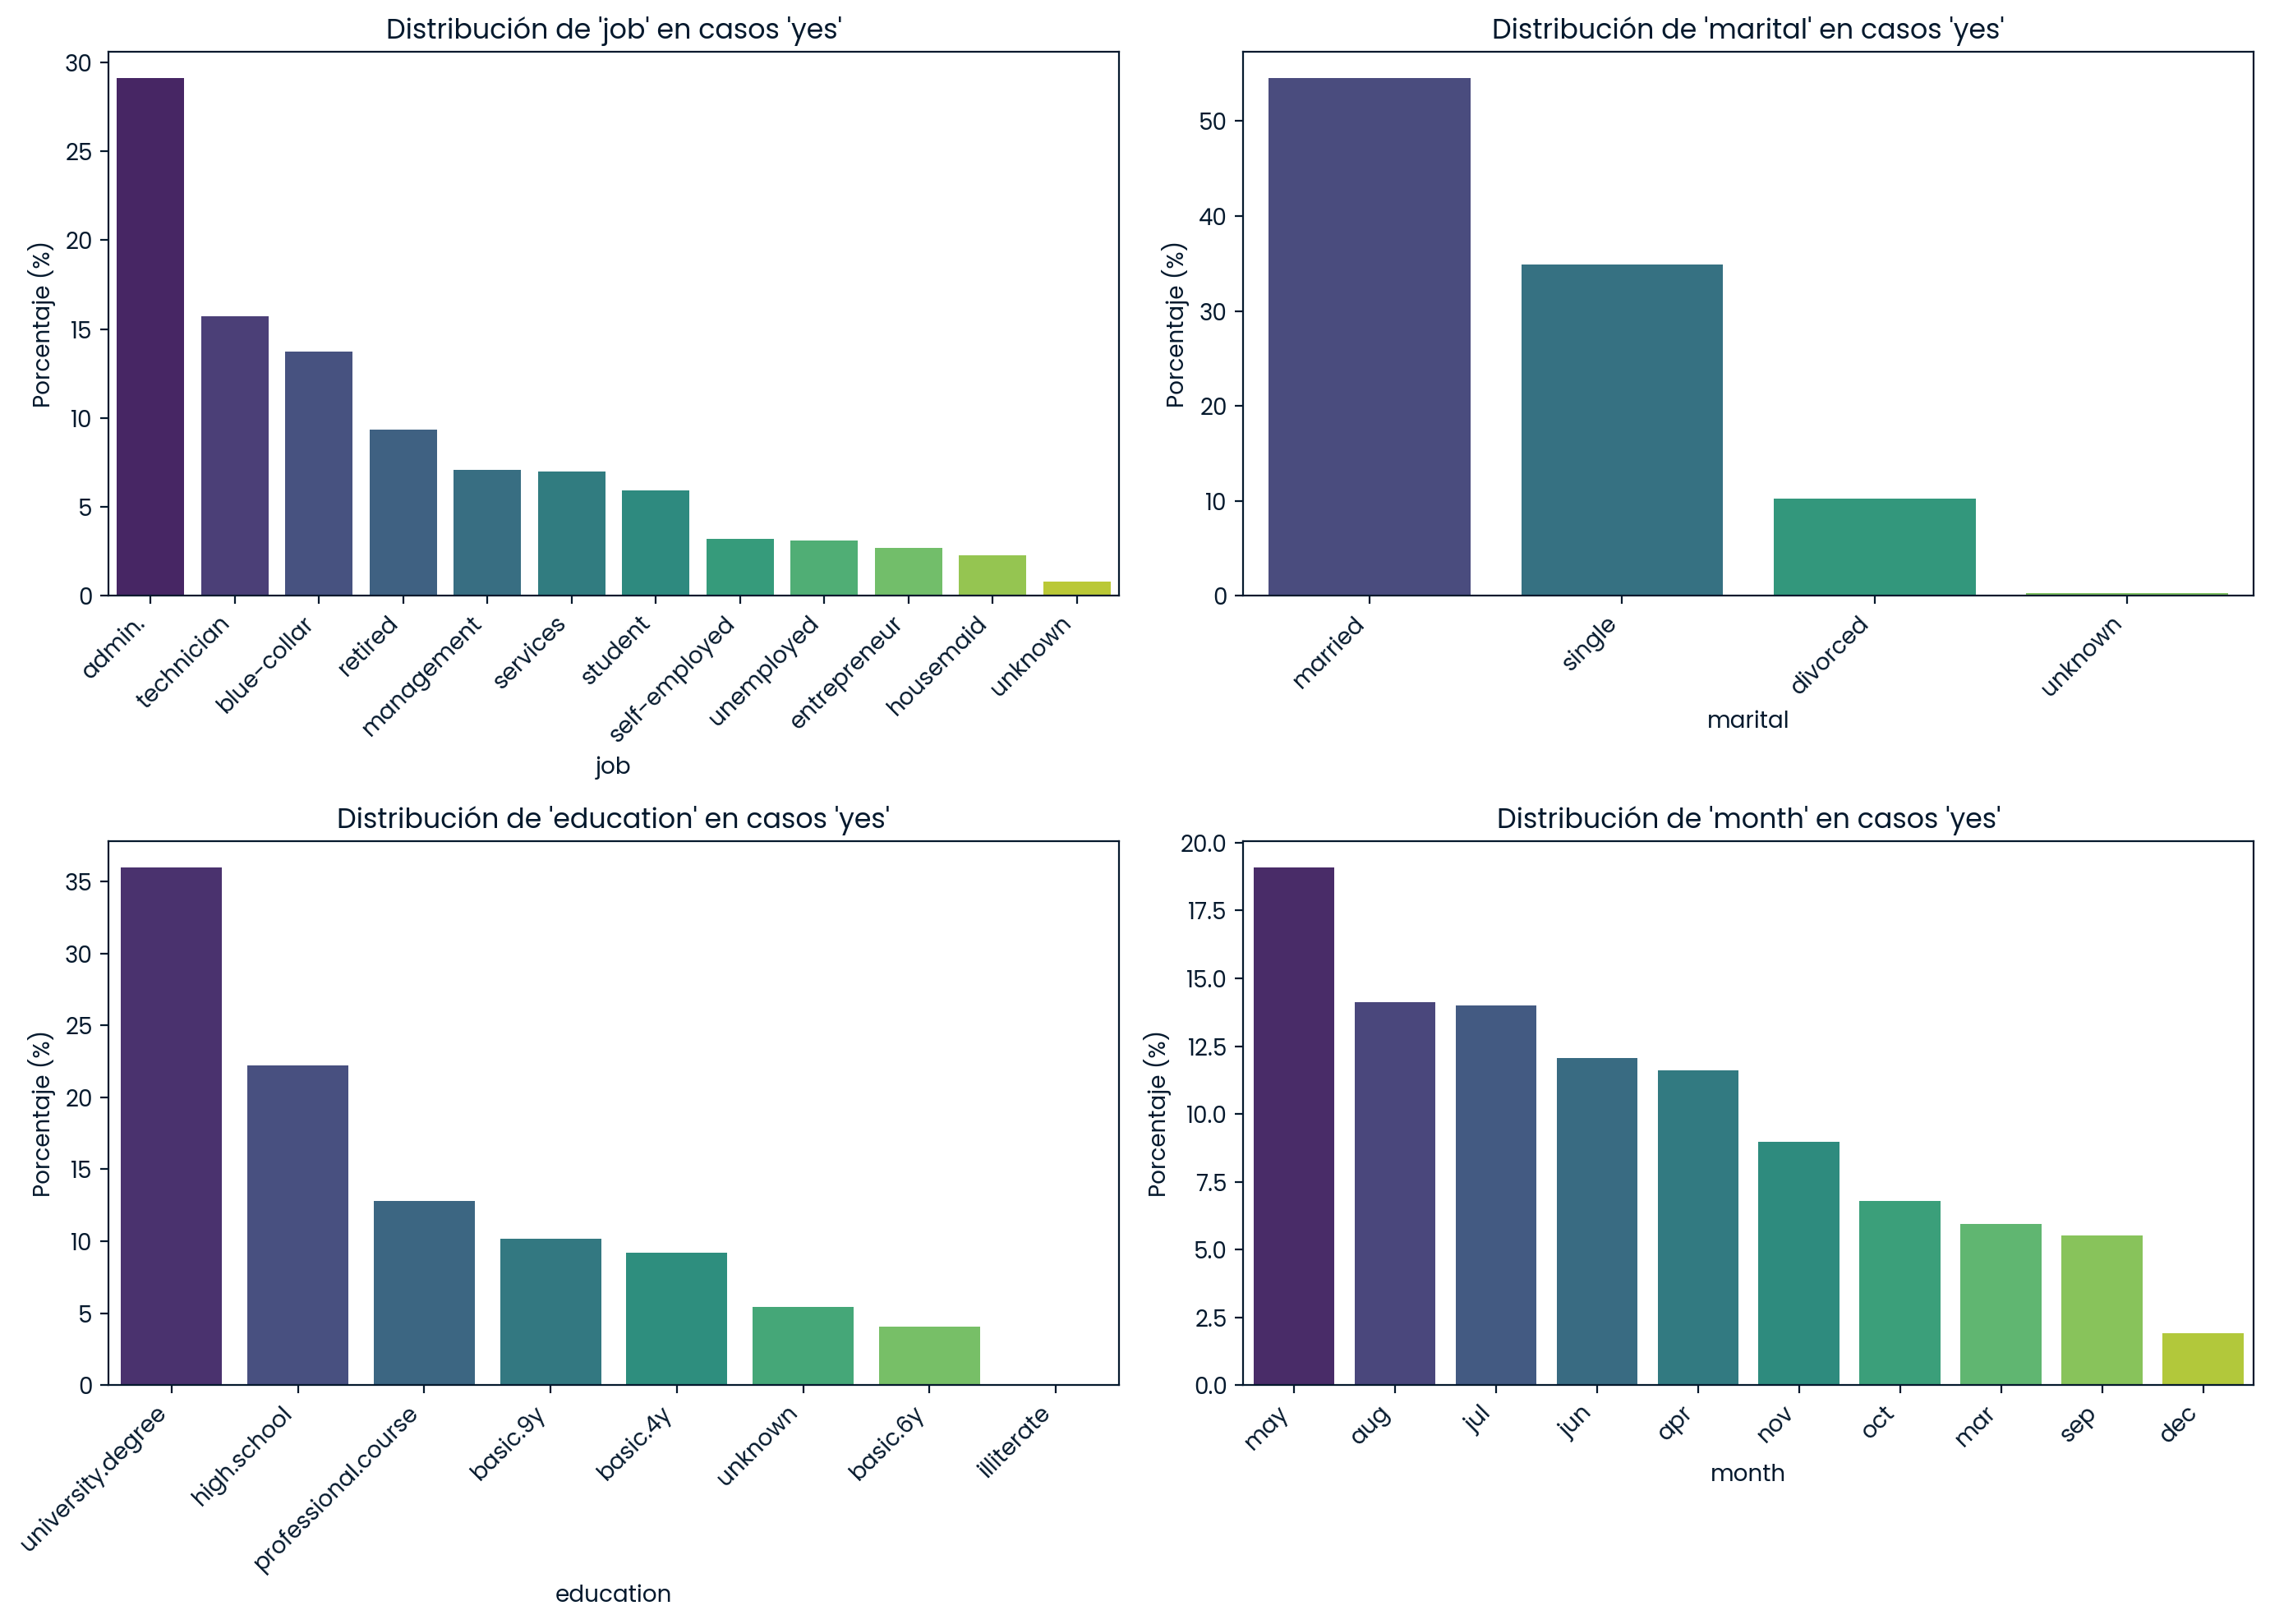

{'job': job
 admin.           29.137931
 technician       15.732759
 blue-collar      13.750000
 retired           9.353448
 management        7.068966
 services          6.961207
 student           5.926724
 self-employed     3.211207
 unemployed        3.103448
 entrepreneur      2.672414
 housemaid         2.284483
 unknown           0.797414
 Name: proportion, dtype: float64,
 'marital': marital
 married     54.568966
 single      34.913793
 divorced    10.258621
 unknown      0.258621
 Name: proportion, dtype: float64,
 'education': education
 university.degree      35.991379
 high.school            22.219828
 professional.course    12.823276
 basic.9y               10.193966
 basic.4y                9.224138
 unknown                 5.409483
 basic.6y                4.051724
 illiterate              0.086207
 Name: proportion, dtype: float64,
 'month': month
 may    19.094828
 aug    14.116379
 jul    13.987069
 jun    12.047414
 apr    11.616379
 nov     8.965517
 oct     6.7887

In [53]:
# Configuración para gráficos
categorical_vars = ['job', 'marital', 'education', 'month']

# Análisis de patrones en variables categóricas
patterns = {}
for var in categorical_vars:
    # Frecuencia relativa por categoría para casos "yes"
    patterns[var] = yes_cases[var].value_counts(normalize=True) * 100

# Gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(categorical_vars):
    sns.barplot(
        x=patterns[var].index, y=patterns[var].values, ax=axes[i], palette="viridis"
    )
    axes[i].set_title(f"Distribución de '{var}' en casos 'yes'")
    axes[i].set_ylabel("Porcentaje (%)")
    axes[i].set_xticklabels(patterns[var].index, rotation=45, ha="right")

plt.tight_layout()
plt.show()

patterns

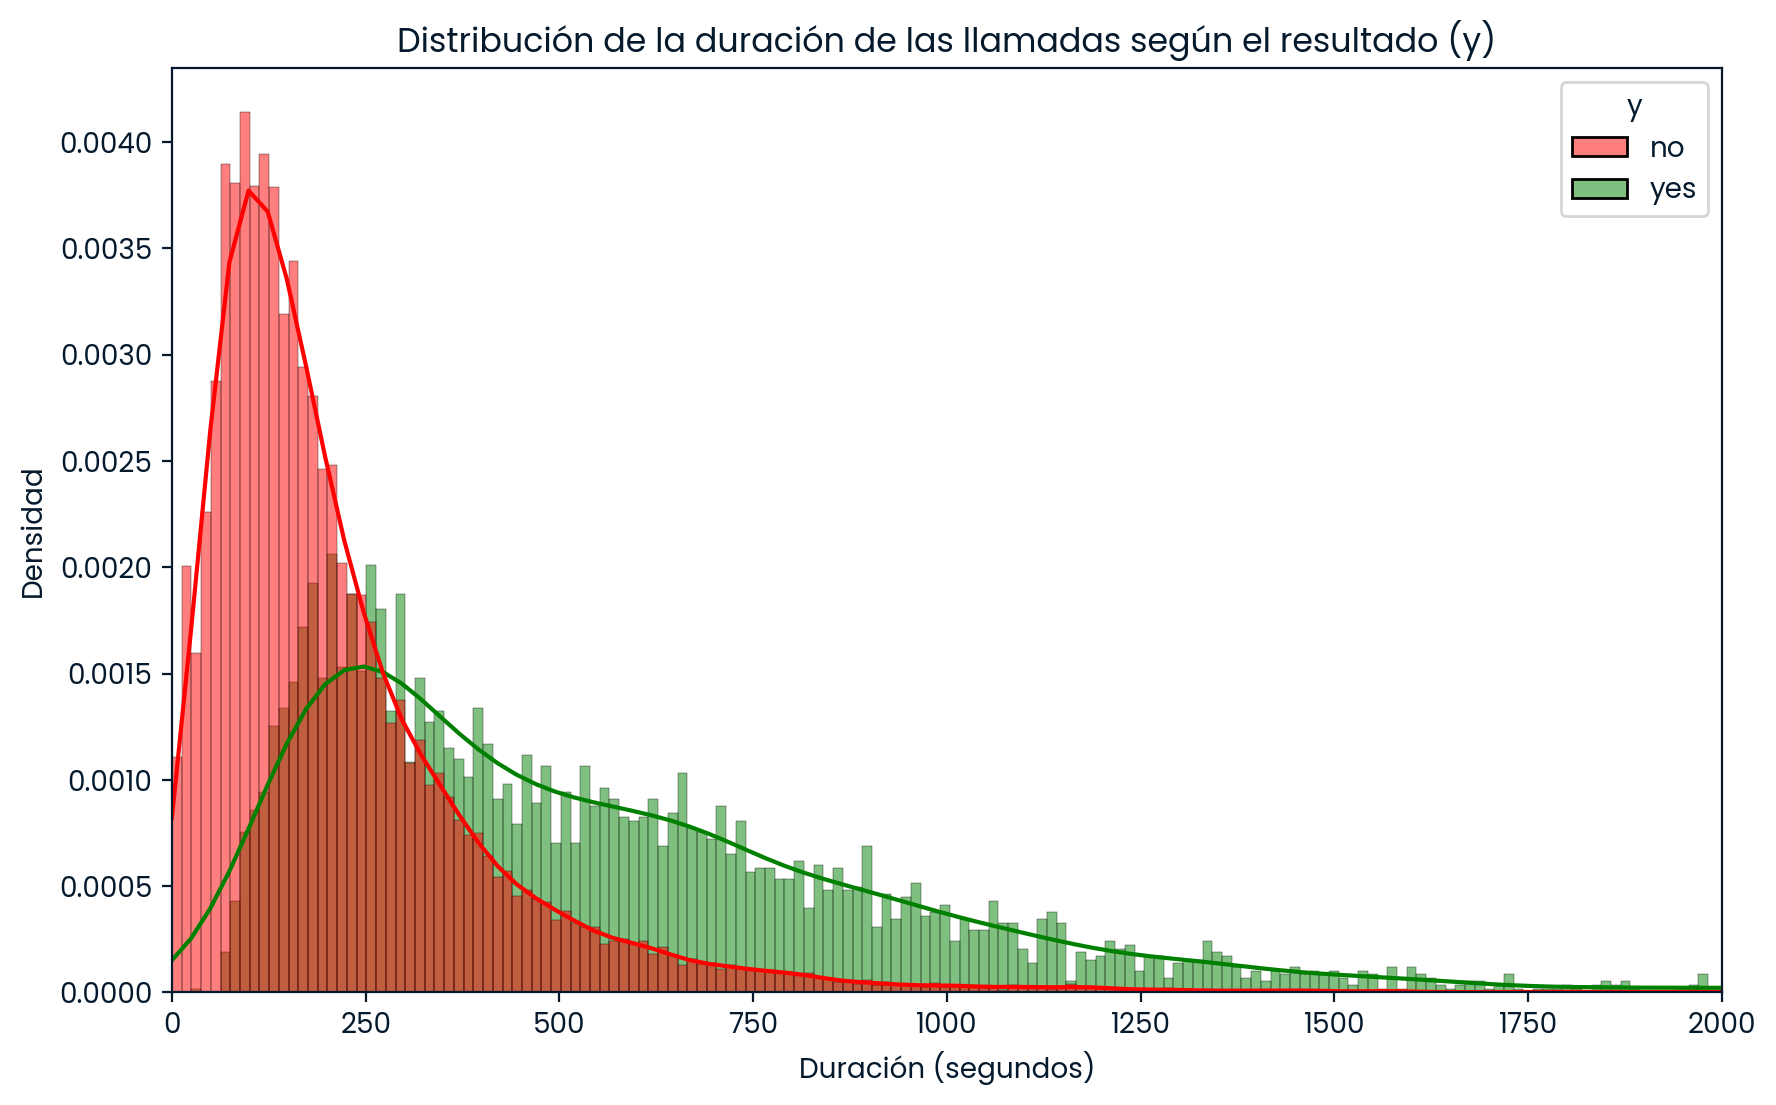

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,36548.0,220.844807,207.096293,0.0,95.0,163.5,279.00,4918.0
yes,4640.0,553.191164,401.171871,37.0,253.0,449.0,741.25,4199.0


In [7]:
# Resumen estadístico de 'duration' para casos 'yes' y 'no'
duration_stats = data.groupby('y')['duration'].describe()

# Visualización de la distribución de 'duration' para 'yes' y 'no'
plt.figure(figsize=(10, 6))
sns.histplot(data, x='duration', hue='y', kde=True, stat="density", common_norm=False, palette={"yes": "green", "no": "red"}, alpha=0.5)
plt.title('Distribución de la duración de las llamadas según el resultado (y)')
plt.xlabel('Duración (segundos)')
plt.ylabel('Densidad')
plt.xlim(0, 2000)  # Limitamos para evitar valores extremos que dominen el gráfico
plt.show()

duration_stats


    euribor3m                                                        campaign  \
        count      mean       std    min    25%    50%    75%    max    count   
y                                                                               
no    36548.0  3.811491  1.638187  0.634  1.405  4.857  4.962  5.045  36548.0   
yes    4640.0  2.123135  1.742598  0.634  0.849  1.266  4.406  5.045   4640.0   

                                                  previous            \
         mean       std  min  25%  50%  75%   max    count      mean   
y                                                                      
no   2.633085  2.873438  1.0  1.0  2.0  3.0  56.0  36548.0  0.132374   
yes  2.051724  1.666245  1.0  1.0  2.0  2.0  23.0   4640.0  0.492672   

                                        
          std  min  25%  50%  75%  max  
y                                       
no   0.409199  0.0  0.0  0.0  0.0  7.0  
yes  0.860344  0.0  0.0  0.0  1.0  6.0  


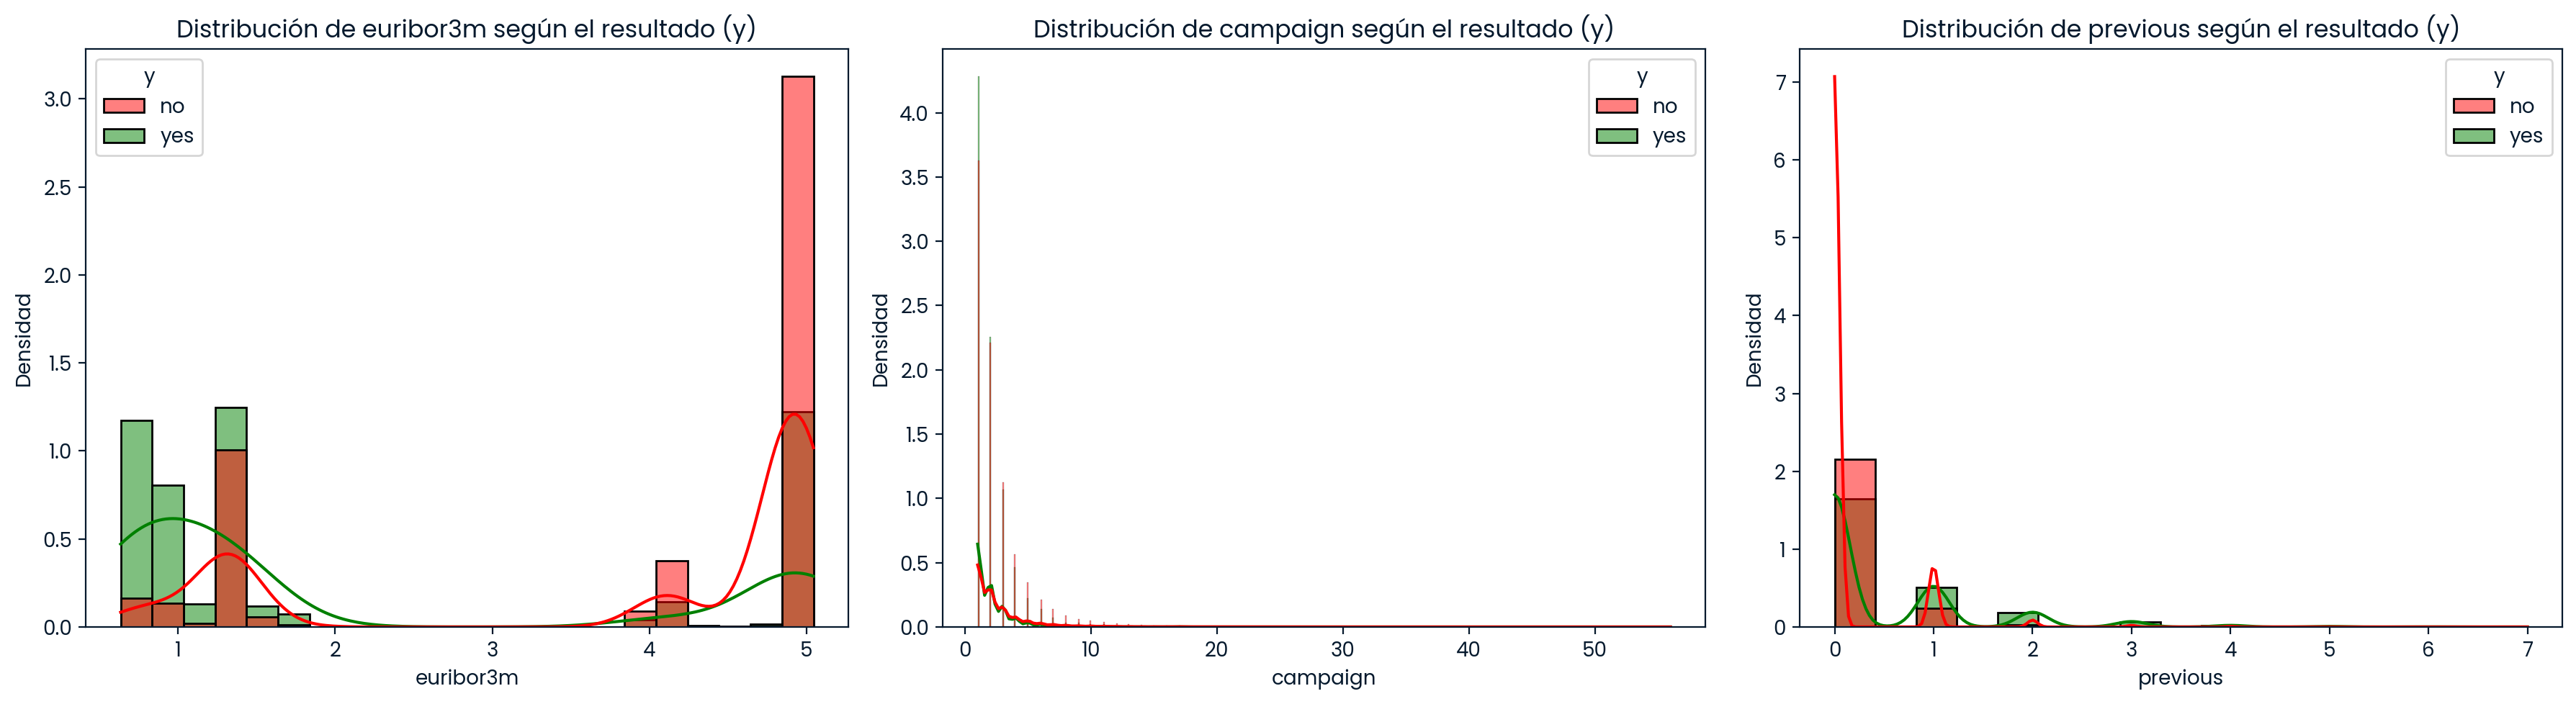

In [54]:
# Variables numéricas a analizar
numeric_vars = ['euribor3m', 'campaign', 'previous']

# Resumen estadístico
numeric_stats = data.groupby('y')[numeric_vars].describe()
print(numeric_stats)

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, var in enumerate(numeric_vars):
    sns.histplot(data, x=var, hue='y', kde=True, stat="density", common_norm=False, ax=axes[i],
                 palette={"yes": "green", "no": "red"}, alpha=0.5)
    axes[i].set_title(f"Distribución de {var} según el resultado (y)")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Densidad")
plt.tight_layout()
plt.show()


Distribución de 'poutcome' según 'y':
poutcome  failure  nonexistent  success
y                                      
no           3647        32422      479
yes           605         3141      894


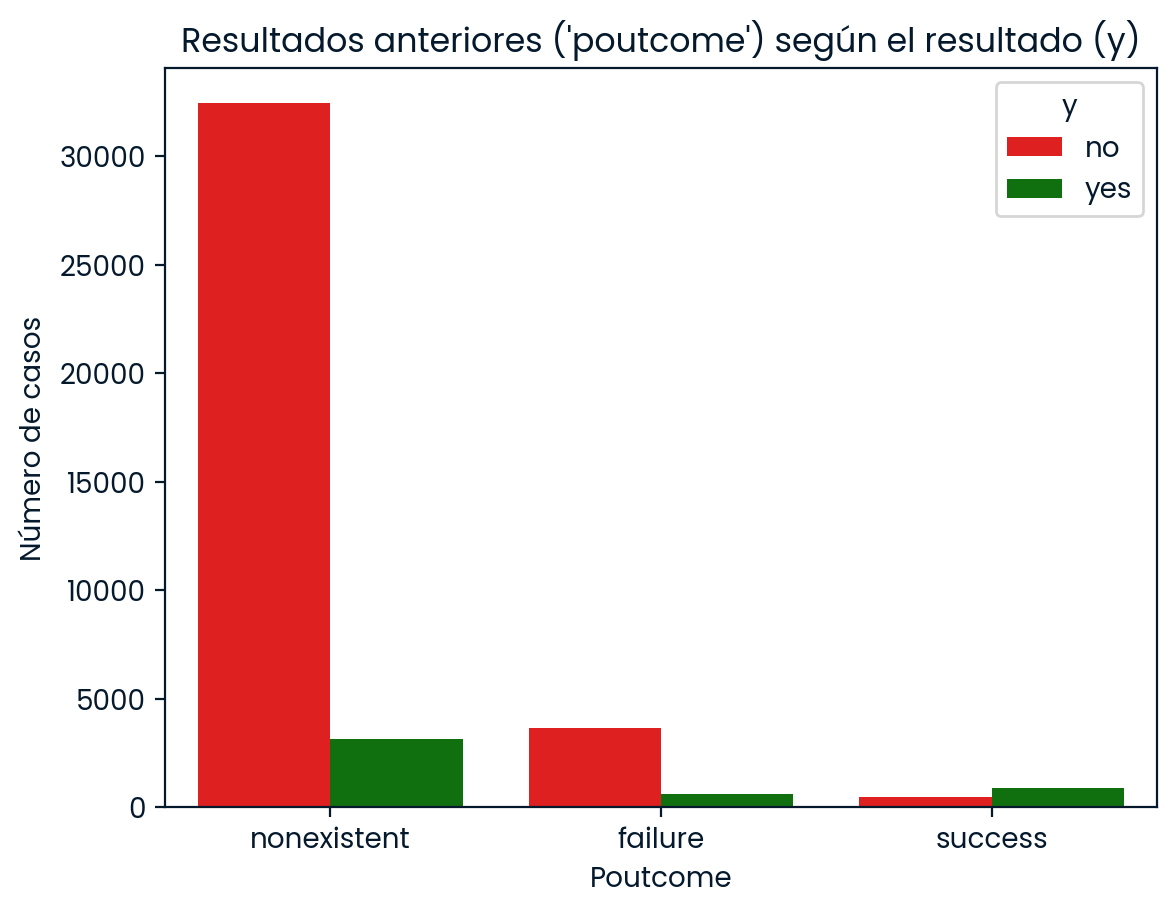

Resumen de 'previous' según 'y':
       count      mean       std  min  25%  50%  75%  max
y                                                        
no   36548.0  0.132374  0.409199  0.0  0.0  0.0  0.0  7.0
yes   4640.0  0.492672  0.860344  0.0  0.0  0.0  1.0  6.0


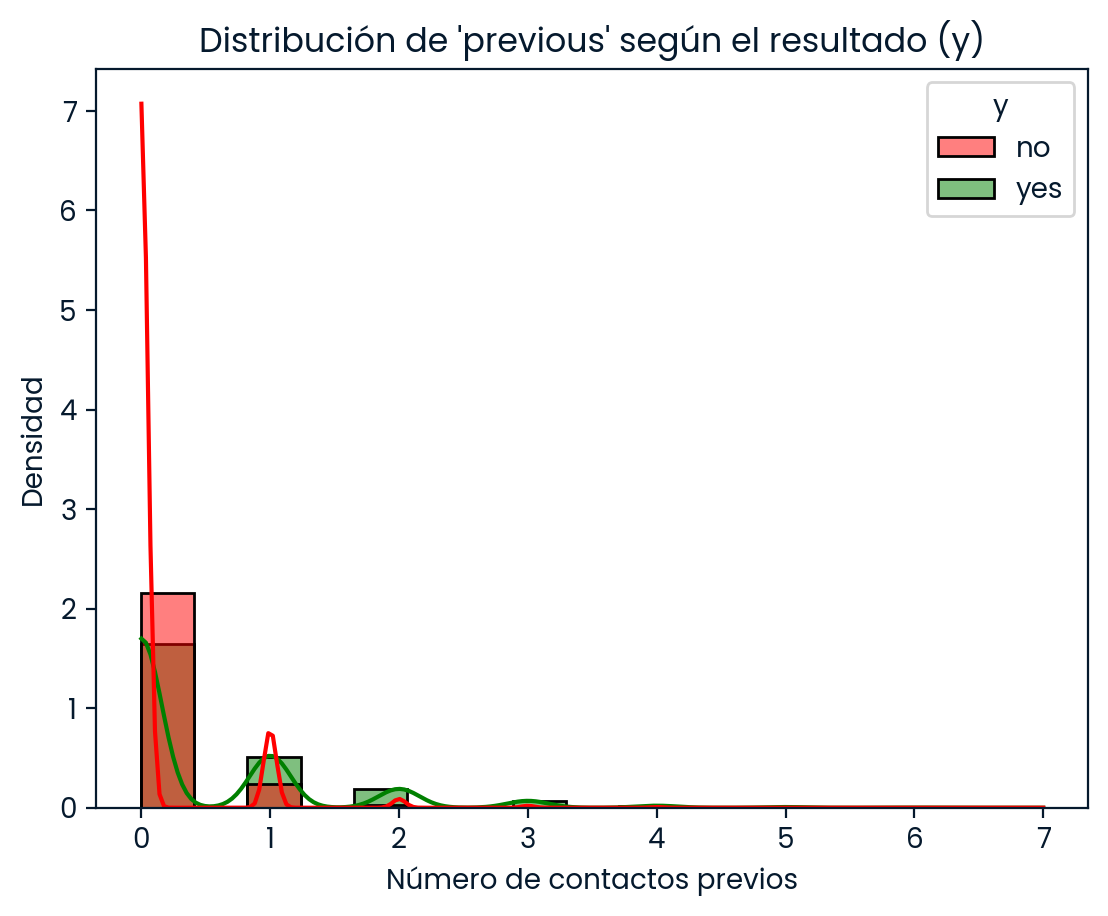

In [55]:
# Resumen de 'poutcome' y su impacto en 'y'
poutcome_counts = data.groupby(['y', 'poutcome']).size().unstack(fill_value=0)
print("Distribución de 'poutcome' según 'y':")
print(poutcome_counts)

# Visualización de 'poutcome'
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=data, x='poutcome', hue='y', palette={"yes": "green", "no": "red"})
plt.title("Resultados anteriores ('poutcome') según el resultado (y)")
plt.xlabel("Poutcome")
plt.ylabel("Número de casos")
plt.show()

# Relación entre 'previous' y 'y'
print("Resumen de 'previous' según 'y':")
previous_stats = data.groupby('y')['previous'].describe()
print(previous_stats)

# Visualización de 'previous'
sns.histplot(data, x='previous', hue='y', kde=True, stat="density", common_norm=False,
             palette={"yes": "green", "no": "red"}, alpha=0.5)
plt.title("Distribución de 'previous' según el resultado (y)")
plt.xlabel("Número de contactos previos")
plt.ylabel("Densidad")
plt.show()


Promedio de variables numéricas según 'y':


y,no,yes
age,39.911185,40.913147
duration,220.844807,553.191164
campaign,2.633085,2.051724
pdays,984.113878,792.035560
previous,0.132374,0.492672
emp.var.rate,0.248875,-1.233448
cons.price.idx,93.603757,93.354386
cons.conf.idx,-40.593097,-39.789784
euribor3m,3.811491,2.123135
nr.employed,5176.166600,5095.115991


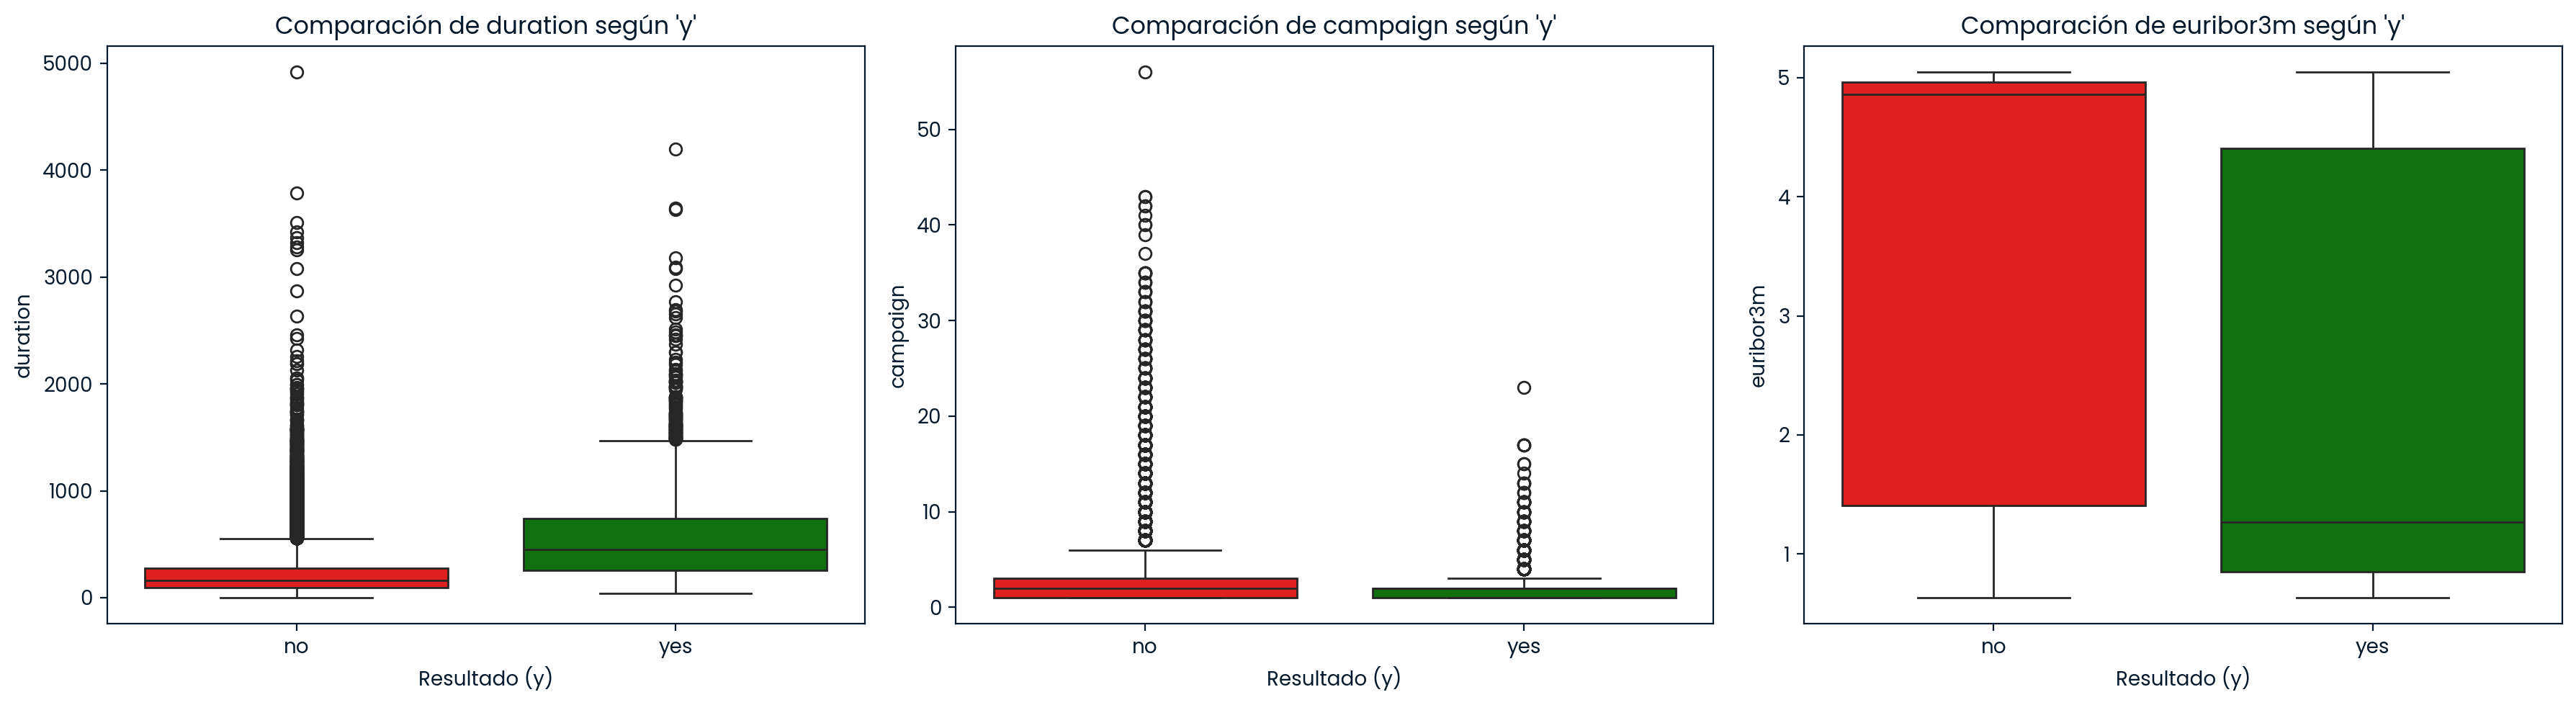

In [56]:
# Compararamos estadísticas generales entre 'yes' y 'no'
# Filtramos solo las columnas numéricas para evitar errores de tipo
numeric_data = data.select_dtypes(include=['number'])
comparison_stats = numeric_data.groupby(data['y']).mean()
print("Promedio de variables numéricas según 'y':")
display(comparison_stats.T)

# Gráfico de comparación para algunas variables clave
import seaborn as sns
import matplotlib.pyplot as plt

key_vars = ['duration', 'campaign', 'euribor3m']  # Cambiaremos o agregararemos más variables según interés
fig, axes = plt.subplots(1, len(key_vars), figsize=(18, 5))

for i, var in enumerate(key_vars):
    sns.boxplot(data=data, x='y', y=var, palette={"yes": "green", "no": "red"}, ax=axes[i])
    axes[i].set_title(f"Comparación de {var} según 'y'")
    axes[i].set_xlabel("Resultado (y)")
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

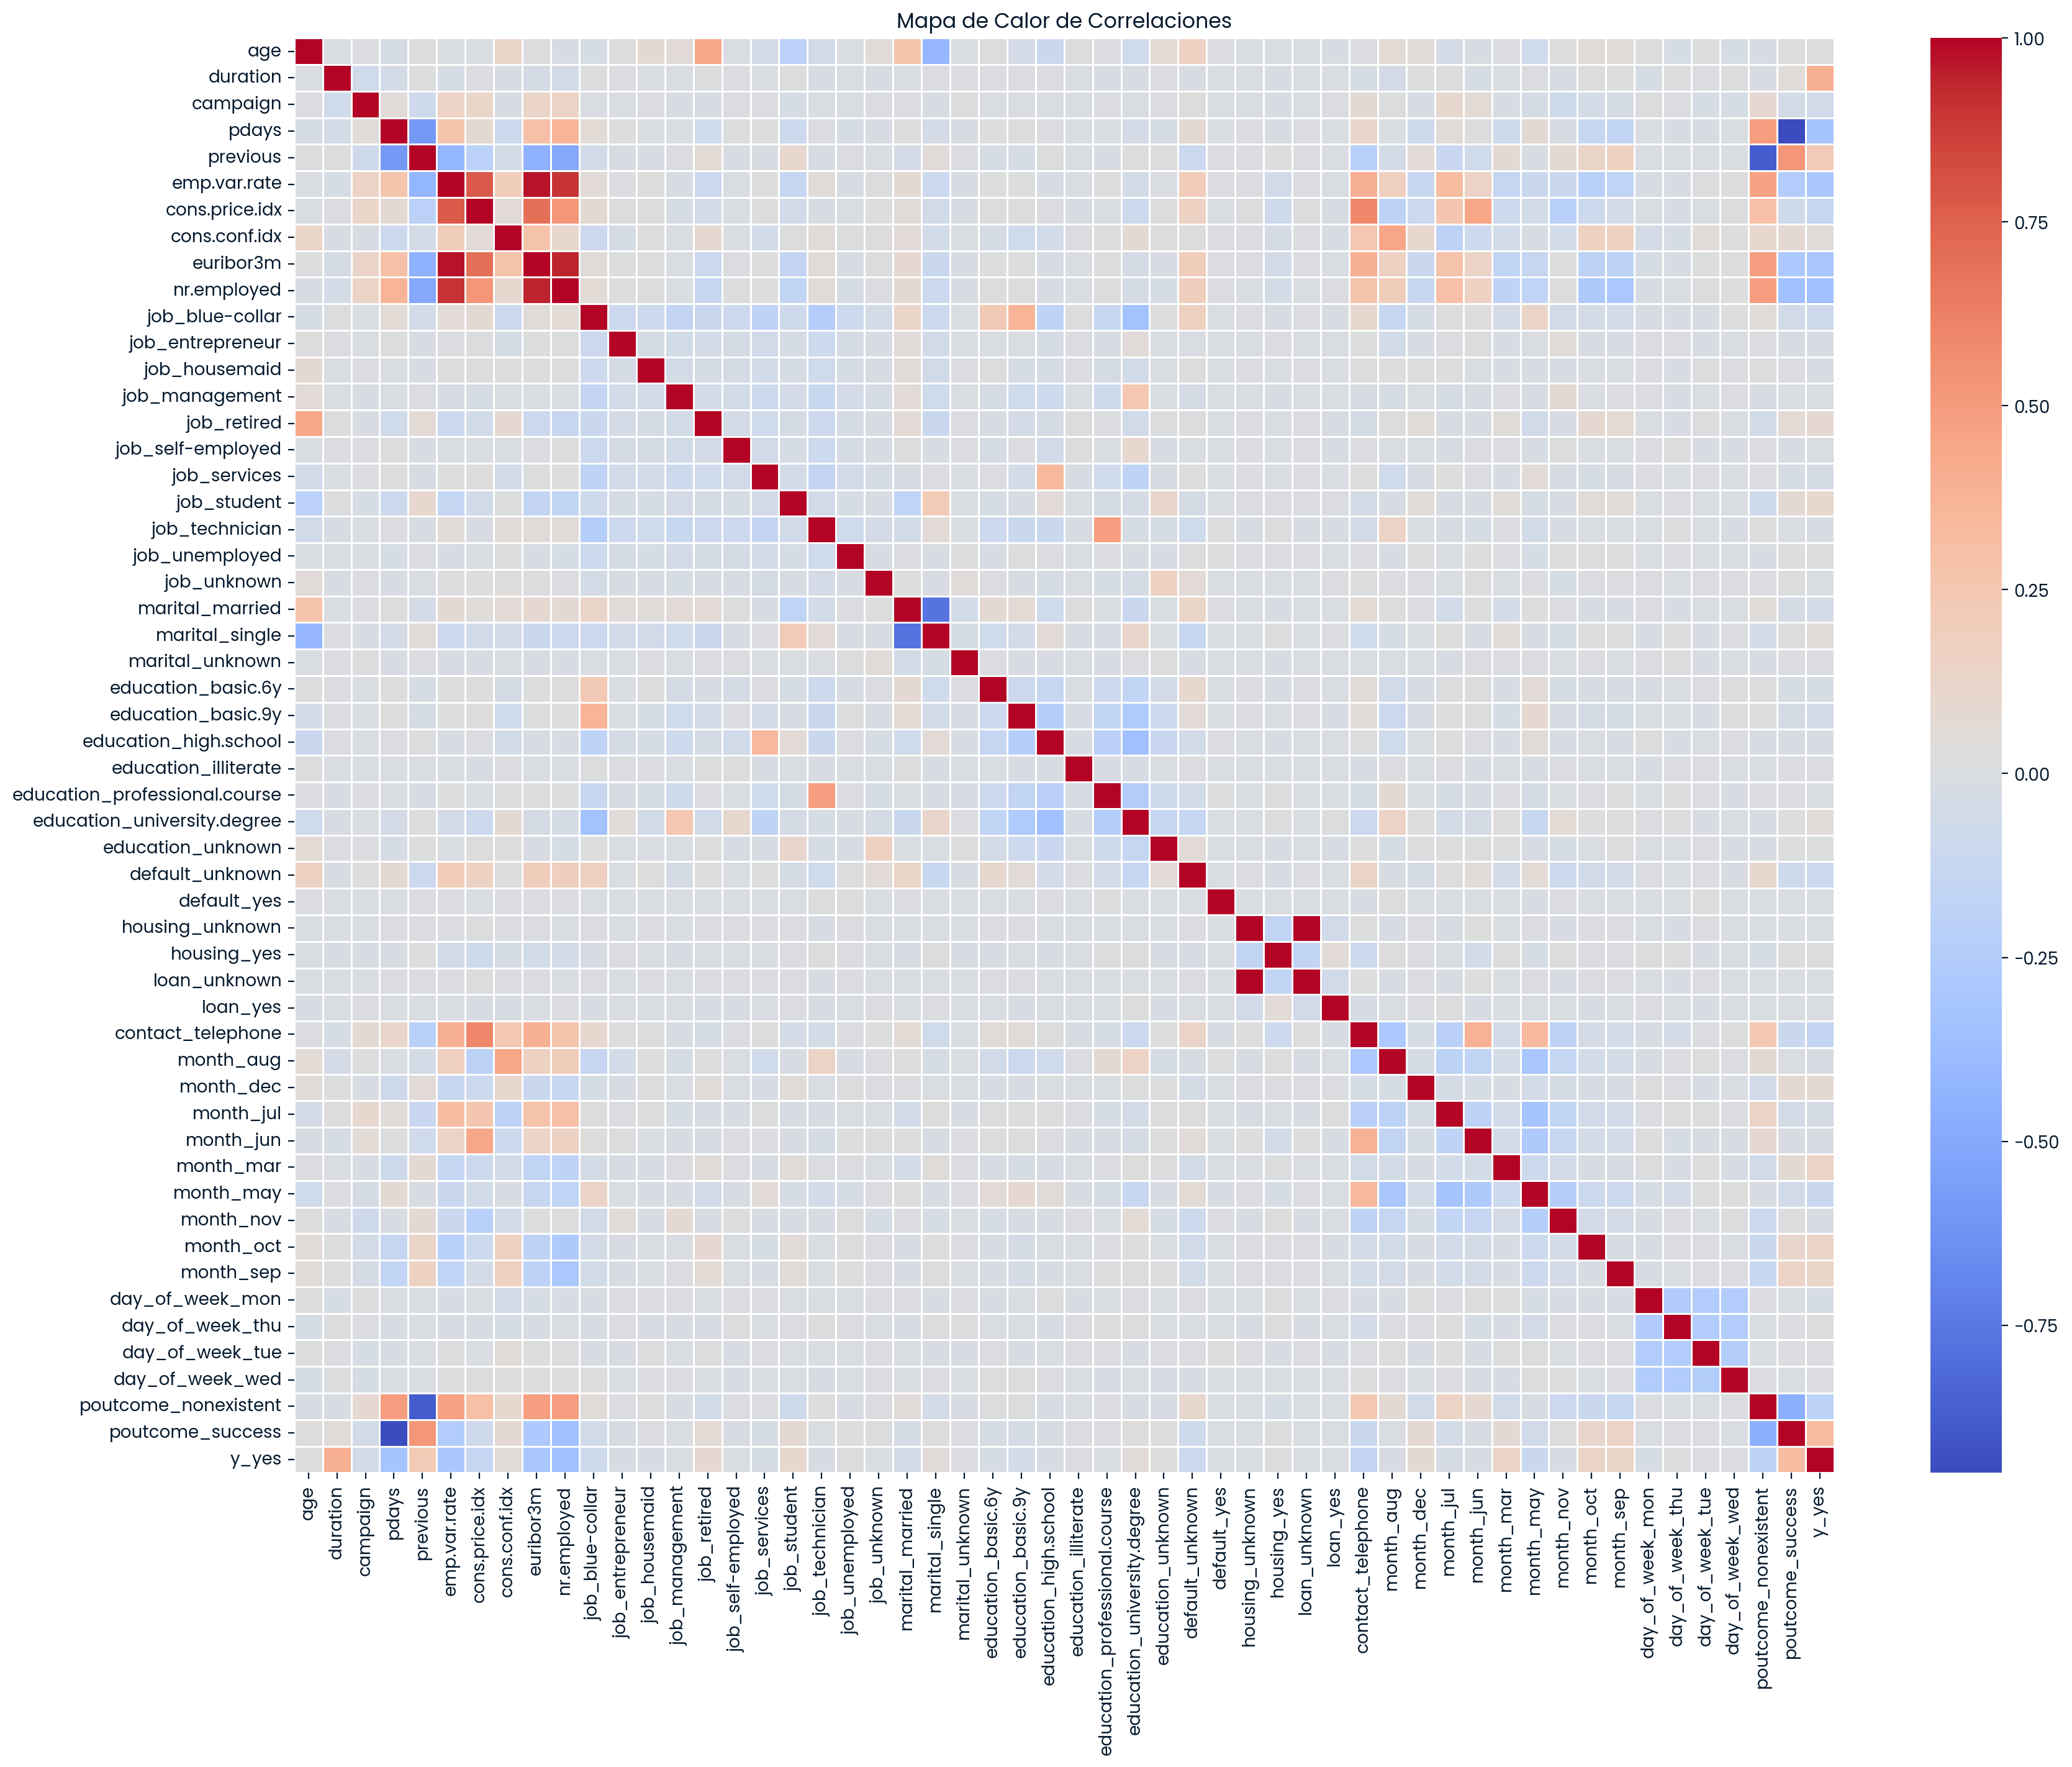

In [57]:
# Convertir todas las variables categóricas a variables dummy, sin cambiar 'y'
data_dum = pd.get_dummies(data, drop_first=True)

# Calcular la matriz de correlación
corr_matrix = data_dum.corr()

# Graficar el mapa de calor
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones")
plt.show()


**Variables más correlacionadas:**

- **duration (0.41)**: Relación positiva moderada con la variable objetivo `y`. Podría ser una variable clave para predecir si un cliente aceptará el depósito.
- **poutcome_success (0.32)**: Relación moderada, lo que indica que el resultado previo del contacto tiene algo de influencia sobre la aceptación.
- **previous (0.23)**: Una correlación positiva moderada, lo que sugiere que los clientes con más interacciones previas podrían estar más dispuestos a aceptar el depósito.

**Variables ligeramente correlacionadas:**

- **month_mar (0.14), month_oct (0.14), month_sep (0.13)**: Los meses en los que se realizan las campañas de contacto tienen una correlación positiva baja, lo que sugiere que el mes podría tener alguna influencia, pero no es un factor principal.
- **job_student, job_retired (0.09)**: Las personas que son estudiantes o jubilados tienen una correlación baja con la aceptación, lo que sugiere que su probabilidad de aceptar es relativamente baja, pero no es completamente irrelevante.

**Variables con baja o casi nula correlación:**

Varias variables tienen correlaciones cercanas a 0 (como `education_unknown`, `job_unemployed`, `day_of_week_thu`, `housing_yes`, entre otras). Estas variables podrían no ser útiles para el modelo, ya que no aportan información significativa para predecir si un cliente aceptará el depósito.

**Variables menos correlacionadas:**

- **emp.var.rate (-0.30), euribor3m (-0.31), pdays (-0.32)**: Tienen correlaciones negativas moderadas, lo que sugiere que a medida que estas variables aumentan, la probabilidad de que el cliente acepte el depósito disminuye.
- **nr.employed (-0.35)**: La correlación negativa más fuerte con `y`. Esto podría indicar que más empleados en una empresa o región podría estar asociado con una menor probabilidad de aceptación del depósito.

Recomendaciones estratégicas:
1. Optimizar la duración de las llamadas:
- Entrenar a los agentes para extender las llamadas cuando el cliente muestra interés, apuntando a un promedio de al menos 5-7 minutos.
2. Segmentar campañas:
- Priorizar clientes con ocupaciones administrativas, técnicas o que estén en la educación superior (university.degree).
- Dirigirse a clientes single y married para maximizar el retorno.
3. Aprovechar meses clave:

- Concentrar campañas de marketing en mayo, julio y agosto para aprovechar los períodos con mayor éxito.
4.Historial previo:
-  Focalizar esfuerzos en clientes con resultados previos positivos (poutcome = success) y diseñar estrategias para capitalizar relaciones existentes.
5. Simplificar contactos:
- Limitar el número de contactos por campaña a un máximo de 2-3 para evitar desgastar al cliente.

In [58]:
# Variables de entrada
target = 'y'

# Variables categóricas
categorical_vars = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']

# Variables numéricas (agregamos 'nr.employed')
numeric_vars = ['age', 'duration', 'campaign', 'pdays', 'previous', 'euribor3m', 'emp.var.rate', 
                'cons.price.idx', 'cons.conf.idx', 'nr.employed']  

# Revisamos las variables antes de usarlas en el modelo
print("Variables categóricas:", categorical_vars)
print("Variables numéricas:", numeric_vars)


Variables categóricas: ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']
Variables numéricas: ['age', 'duration', 'campaign', 'pdays', 'previous', 'euribor3m', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']


In [59]:
# Dividimos los datos en entrenamiento y prueba
X = data[categorical_vars + numeric_vars]  # Seleccionamos las variables de entrada
y = data[target].map({'yes': 1, 'no': 0})  # Convertimos 'yes'/'no' en 1/0

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Ver el tamaño de los conjuntos de entrenamiento y prueba
print(f"Tamaño de entrenamiento: {X_train.shape}")
print(f"Tamaño de prueba: {X_test.shape}")

Tamaño de entrenamiento: (28831, 18)
Tamaño de prueba: (12357, 18)


In [60]:
# Preprocesador para transformar las variables numéricas y categóricas
preprocessor = ColumnTransformer(
    transformers=[
        # Escalamos las variables numéricas
        ('num', StandardScaler(), numeric_vars),
        # Codificamos las variables categóricas usando OneHotEncoder
        ('cat', OneHotEncoder(drop='first'), categorical_vars)
    ]
)

In [61]:
# Creamos el pipeline con SMOTE
smote = SMOTE(sampling_strategy=0.5, random_state=42)  # Creamos el objeto SMOTE
classifier = LogisticRegression(max_iter=1000, class_weight='balanced', penalty='l2', random_state=42)

# Pipeline de modelo con SMOTE
pipeline_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),  # Añadir SMOTE para balancear las clases
    ('classifier', classifier)
])

In [62]:
# Entrenar el modelo
pipeline_smote.fit(X_train, y_train)

# Hacer predicciones
y_pred = pipeline_smote.predict(X_test)

# Evaluación del modelo
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.86      0.92     10965
           1       0.45      0.89      0.60      1392

    accuracy                           0.86     12357
   macro avg       0.72      0.88      0.76     12357
weighted avg       0.92      0.86      0.88     12357

Confusion Matrix:
 [[9440 1525]
 [ 149 1243]]


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      0.86      0.92     10965
           1       0.45      0.89      0.60      1392

    accuracy                           0.86     12357
   macro avg       0.72      0.88      0.76     12357
weighted avg       0.92      0.86      0.88     12357

AUC-ROC: 0.9393992641162319
Matriz de confusión:
[[9440 1525]
 [ 149 1243]]


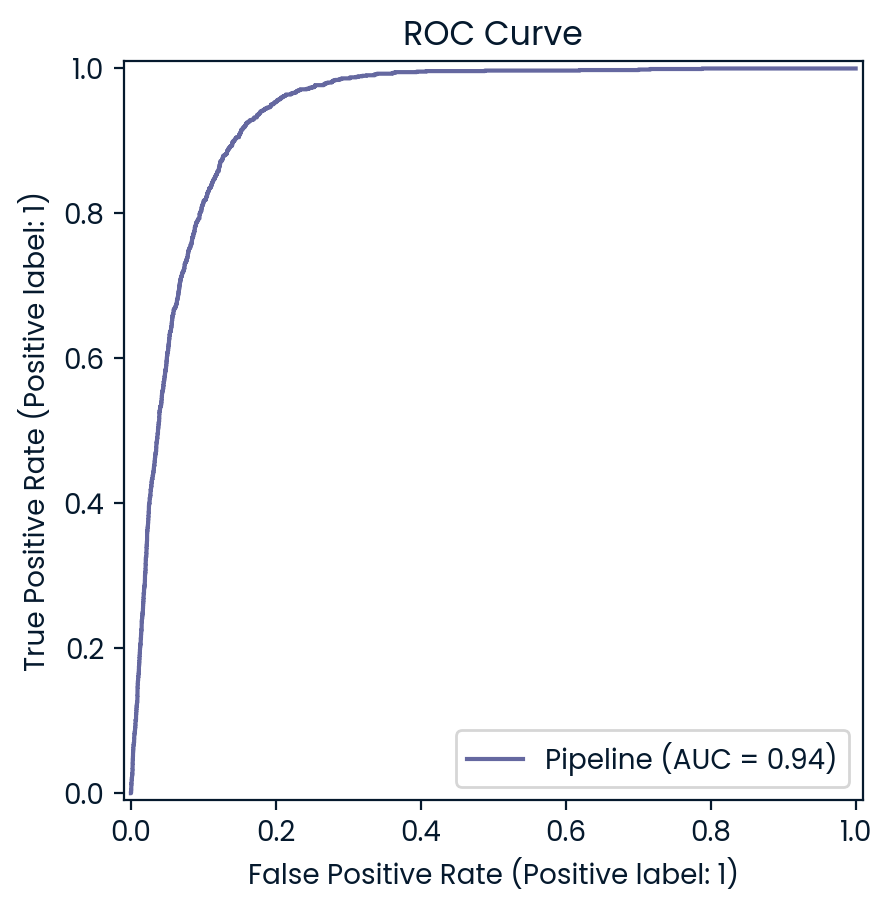

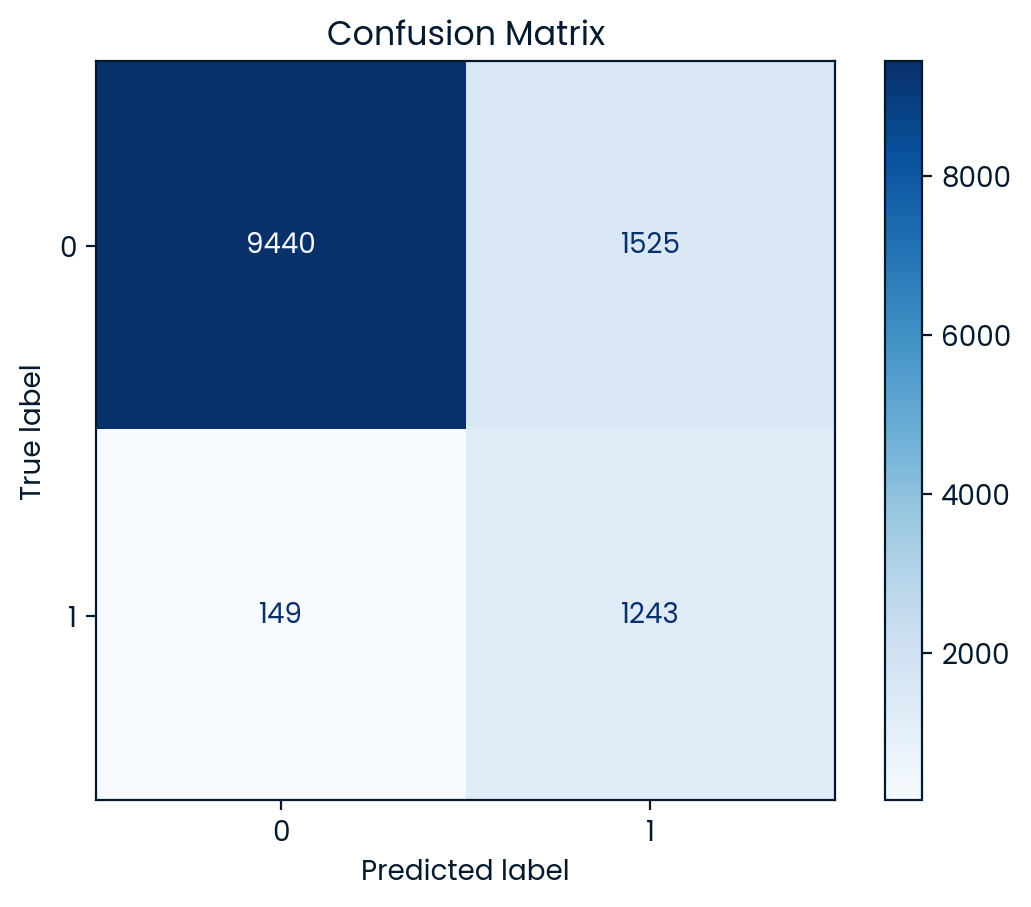

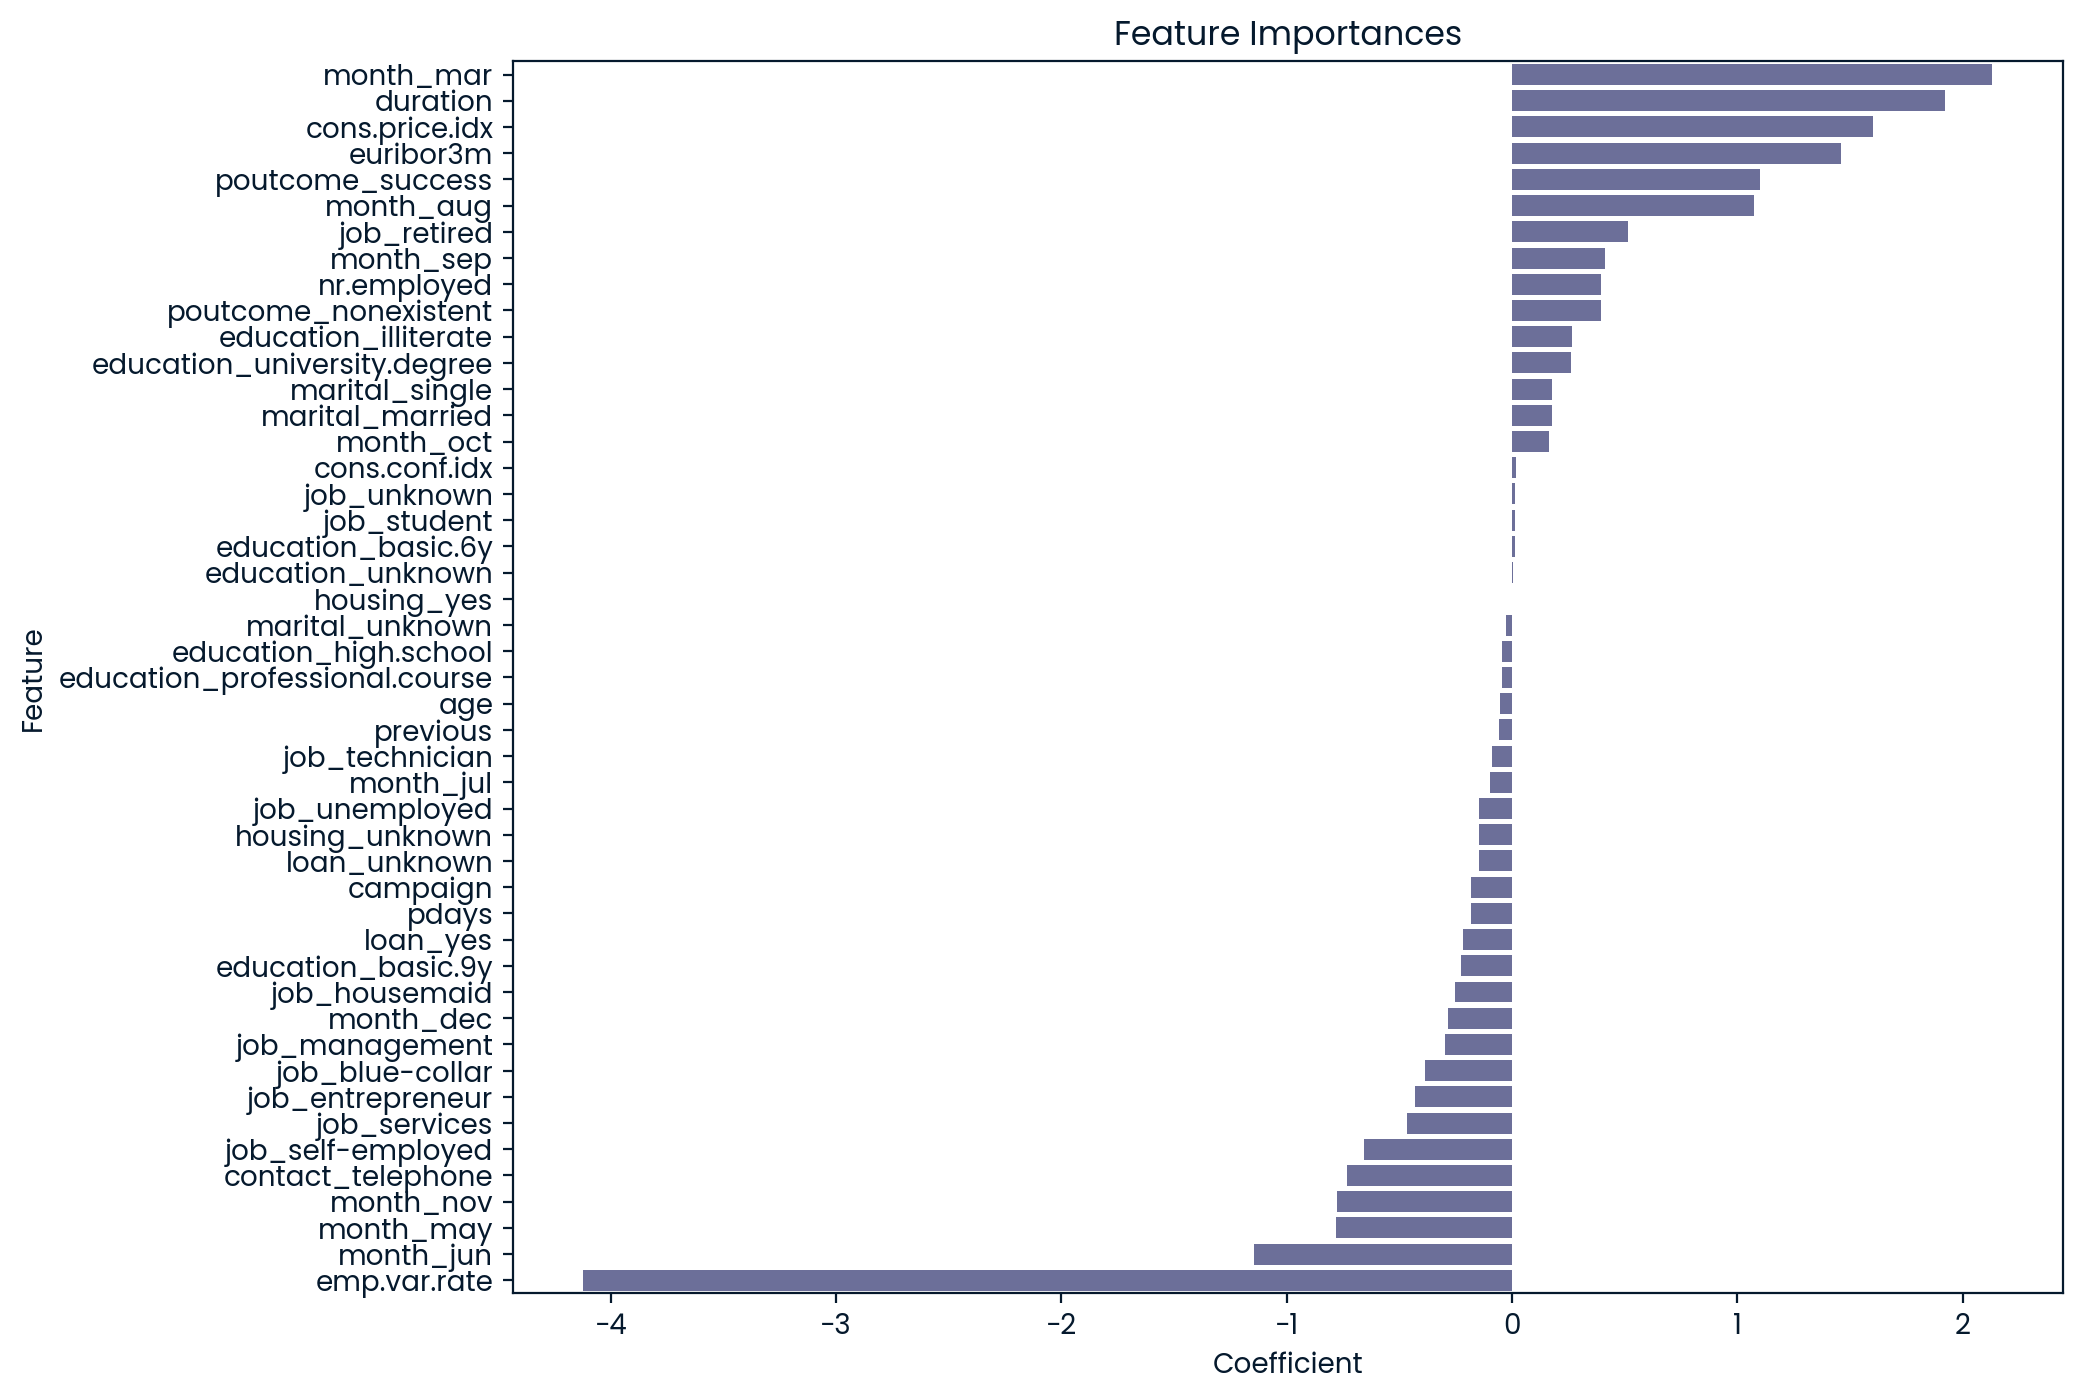

In [63]:
# Reporte de clasificación
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

# AUC-ROC
y_pred_proba = pipeline_smote.predict_proba(X_test)[:, 1]
print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba))

# Matriz de confusión
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# Plot ROC Curve
RocCurveDisplay.from_estimator(pipeline_smote, X_test, y_test)
plt.title('ROC Curve')
plt.show()

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(pipeline_smote, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Plot Feature Importances (for Logistic Regression coefficients)
feature_names = numeric_vars + list(pipeline_smote.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_vars))
coefficients = pipeline_smote.named_steps['classifier'].coef_[0]

# Creamos un df para mejorar la visualización, creando un gráfico
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title('Feature Importances')
plt.show()